# 4.10 · Ноутбук 3. DL-експерименти, фінальна оцінка та аналіз помилок

**Гіпотеза:** згорткова мережа (CNN) краще за лінійну модель використовує просторову структуру зображення (локальні штрихи, їх взаємне розміщення) і стійкіша до невеликих зсувів.

**Контрольовані експерименти** (між сусідніми run змінюється один фактор):
| Run | Зміна | Гіпотеза |
|---|---|---|
| D1 | базова CNN | CNN вловлює нелінійну просторову структуру |
| D2 | + Dropout 0.3 + L2 1e-4 | регуляризація зменшить перенавчання |
| D3 | + аугментація (зсуви, повороти) | аугментація покращить узагальнення і стійкість до зсувів |

Вибір фінальної моделі відбувається **лише за validation**. Test використовується один раз.

In [1]:
import os, json
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 80
sns.set_theme(style="whitegrid")

CFG = json.load(open("../config.json", encoding="utf-8"))
SEED = CFG["seed"]

import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
print("TensorFlow", tf.__version__)

digits = load_digits()
X_img = digits.images.astype("float32") / 16.0          # нормалізація 0..1
y = digits.target
split = np.load("../data/split.npz")
tr, va, te = split["train"], split["val"], split["test"]
Xtr, Xva, Xte = X_img[tr][..., None], X_img[va][..., None], X_img[te][..., None]   # (n, 8, 8, 1)
ytr, yva, yte = y[tr], y[va], y[te]
print(Xtr.shape, Xva.shape, Xte.shape)

I0000 00:00:1790327995.564937   16745 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790327997.051636   16745 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0
(1078, 8, 8, 1) (359, 8, 8, 1) (360, 8, 8, 1)


## 1. Архітектура
```
Input 8×8×1 → [Augmentation (D3)] → Conv2D(32, 3×3, same, ReLU) → Conv2D(32, 3×3, same, ReLU) → MaxPool 2×2
            → Conv2D(64, 3×3, same, ReLU) → MaxPool 2×2 → Flatten → [Dropout] → Dense(64, ReLU) → [Dropout] → Dense(10, Softmax)
```
Loss: `sparse_categorical_crossentropy`; optimizer: Adam (lr = 1e-3); метрика: accuracy (класи збалансовані), додатково macro-F1. EarlyStopping за `val_loss` (patience = 15) з відновленням найкращих ваг.

In [2]:
C = CFG["cnn"]
def build_cnn(dropout=0.0, l2=0.0, augmentation=False, aug_translation=0.125, aug_rotation=0.04, **_):
    reg = regularizers.l2(l2) if l2 else None
    inp = keras.Input(shape=(8, 8, 1))
    x = inp
    if augmentation:
        x = layers.RandomTranslation(aug_translation, aug_translation, fill_mode="constant")(x)
        x = layers.RandomRotation(aug_rotation, fill_mode="constant")(x)
    f1, f2 = C["conv_filters"]
    x = layers.Conv2D(f1, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = layers.Conv2D(f1, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(f2, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    if dropout: x = layers.Dropout(dropout)(x)
    x = layers.Dense(C["dense_units"], activation="relu", kernel_regularizer=reg)(x)
    if dropout: x = layers.Dropout(dropout)(x)
    out = layers.Dense(10, activation="softmax")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(C["learning_rate"]),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

build_cnn(**CFG["runs"]["D3"]).summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 8, 8, 1)        │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 8, 8, 1)        │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 8, 8, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,162 (176.41 KB)

 Trainable params: 45,162 (176.41 KB)

 Non-trainable params: 0 (0.00 B)

## 2. Контрольовані експерименти D1–D3

In [3]:
results, histories, models = [], {}, {}
for run_id, params in CFG["runs"].items():
    keras.utils.set_random_seed(SEED)
    model = build_cnn(**params)
    t0 = time.time()
    h = model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=C["max_epochs"], batch_size=C["batch_size"], verbose=0,
                  callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=C["early_stopping_patience"],
                                                           restore_best_weights=True)])
    dt = time.time() - t0
    tr_acc = accuracy_score(ytr, model.predict(Xtr, verbose=0).argmax(1))
    va_pred = model.predict(Xva, verbose=0).argmax(1)
    results.append({"run": run_id, "change": params, "epochs": len(h.history["loss"]),
                    "train_acc": tr_acc, "val_acc": accuracy_score(yva, va_pred),
                    "val_macro_f1": f1_score(yva, va_pred, average="macro"), "time_s": dt})
    histories[run_id], models[run_id] = h.history, model
    print(f"{run_id}: val_acc = {results[-1]['val_acc']:.4f}, epochs = {results[-1]['epochs']}, {dt:.1f} s")

base = pd.read_csv("../results/baseline_metrics.csv")
exp = pd.concat([base, pd.DataFrame(results)], ignore_index=True)
exp["gap"] = exp["train_acc"] - exp["val_acc"]
exp[["run", "train_acc", "val_acc", "val_macro_f1", "gap", "epochs", "time_s"]].round(4)

D1: val_acc = 0.9833, epochs = 50, 17.6 s


D2: val_acc = 0.9889, epochs = 44, 15.4 s


D3: val_acc = 0.9916, epochs = 86, 31.6 s


,run,train_acc,val_acc,val_macro_f1,gap,epochs,time_s
0,B-rule,0.1020,0.1003,NaN,0.0018,NaN,NaN
1,B0,1.0000,0.9666,0.9665,0.0334,NaN,0.0287
2,D1,1.0000,0.9833,0.9831,0.0167,50.0,17.5611
3,D2,1.0000,0.9889,0.9887,0.0111,44.0,15.4189
4,D3,0.9991,0.9916,0.9915,0.0074,86.0,31.5623


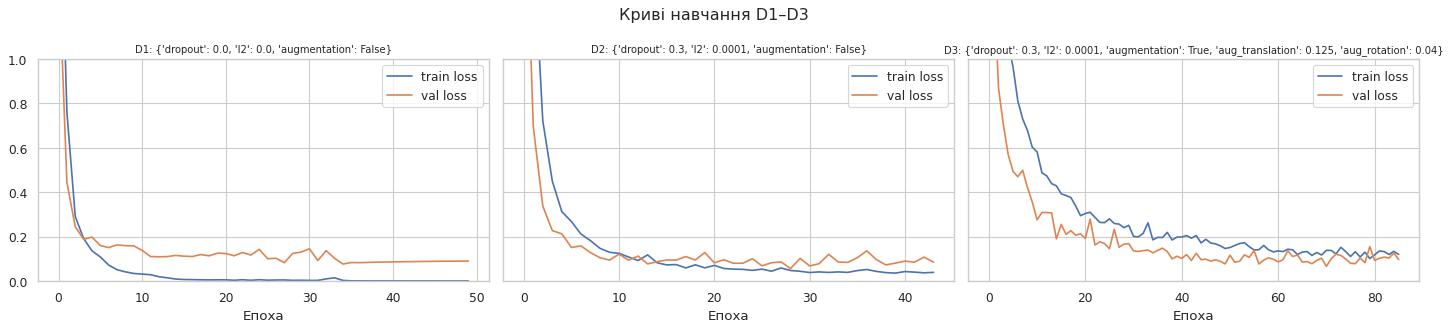

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2), sharey=True)
for ax, (rid, hh) in zip(axes, histories.items()):
    ax.plot(hh["loss"], label="train loss"); ax.plot(hh["val_loss"], label="val loss")
    ax.set_title(f"{rid}: {CFG['runs'][rid]}", fontsize=9); ax.set_xlabel("Епоха"); ax.legend()
axes[0].set_ylim(0, 1)
plt.suptitle("Криві навчання D1–D3"); plt.tight_layout(); plt.show()

## 3. Вибір фінальної моделі
Обираємо run з найвищою `val_acc`. Якщо значення рівні, беремо той, у якого менший розрив train/val. Після цього модель заморожується, і тільки тоді вона та baseline оцінюються на test.

In [5]:
dl = pd.DataFrame(results)
dl["gap"] = dl["train_acc"] - dl["val_acc"]
best_id = dl.sort_values(["val_acc", "gap"], ascending=[False, True]).iloc[0]["run"]
final_model = models[best_id]
print("Обрано:", best_id, CFG["runs"][best_id])

Обрано: D3 {'dropout': 0.3, 'l2': 0.0001, 'augmentation': True, 'aug_translation': 0.125, 'aug_rotation': 0.04}


## 4. Фінальна оцінка на test (одноразово)

In [6]:
scaler = StandardScaler().fit(Xtr.reshape(len(Xtr), -1))
flat = lambda a: scaler.transform(a.reshape(len(a), -1))
logreg = LogisticRegression(C=CFG["baseline"]["C"], max_iter=CFG["baseline"]["max_iter"]).fit(flat(Xtr), ytr)

pred_b0 = logreg.predict(flat(Xte))
pred_dl = final_model.predict(Xte, verbose=0).argmax(1)
final = pd.DataFrame({
    "test_acc": [accuracy_score(yte, pred_b0), accuracy_score(yte, pred_dl)],
    "test_macro_f1": [f1_score(yte, pred_b0, average="macro"), f1_score(yte, pred_dl, average="macro")],
    "test_errors": [(pred_b0 != yte).sum(), (pred_dl != yte).sum()],
}, index=["B0 LogisticRegression", f"FINAL CNN ({best_id})"])
final.round(4)

,test_acc,test_macro_f1,test_errors
B0 LogisticRegression,0.9639,0.9640,13
FINAL CNN (D3),0.9778,0.9773,8


In [7]:
# Bootstrap 95% довірчі інтервали для test accuracy (1000 перевибірок)
rng = np.random.default_rng(SEED)
boot = {"B0": [], "CNN": []}
for _ in range(1000):
    i = rng.integers(0, len(yte), len(yte))
    boot["B0"].append((pred_b0[i] == yte[i]).mean()); boot["CNN"].append((pred_dl[i] == yte[i]).mean())
diff = np.array(boot["CNN"]) - np.array(boot["B0"])
for k, v in boot.items():
    print(f"{k}: 95% CI accuracy = [{np.percentile(v, 2.5):.3f}, {np.percentile(v, 97.5):.3f}]")
print(f"Різниця CNN − B0: 95% CI = [{np.percentile(diff, 2.5):.3f}, {np.percentile(diff, 97.5):.3f}]")

B0: 95% CI accuracy = [0.944, 0.981]


CNN: 95% CI accuracy = [0.964, 0.992]
Різниця CNN − B0: 95% CI = [-0.006, 0.036]


## 5. Аналіз помилок

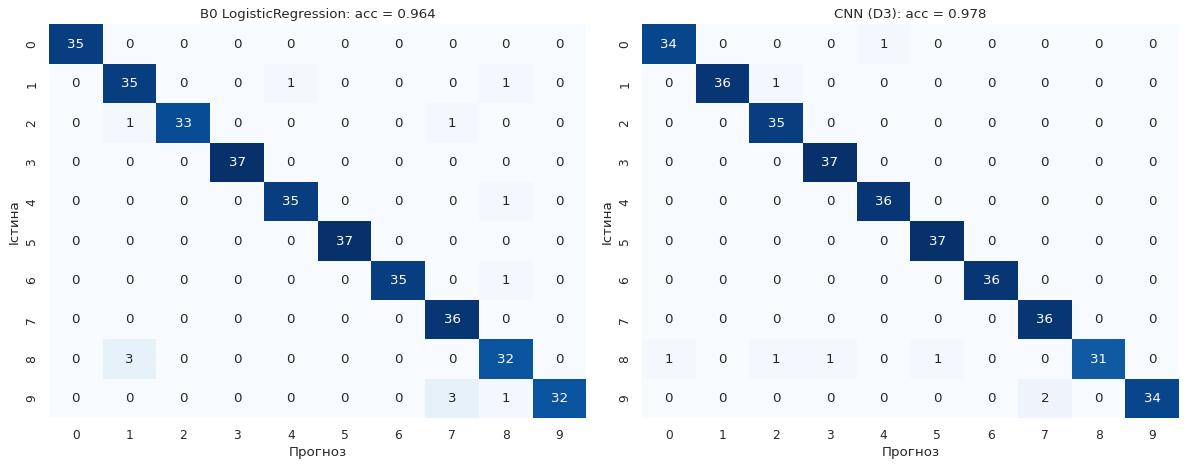

              precision    recall  f1-score   support

           0      0.971     0.971     0.971        35
           1      1.000     0.973     0.986        37
           2      0.946     1.000     0.972        35
           3      0.974     1.000     0.987        37
           4      0.973     1.000     0.986        36
           5      0.974     1.000     0.987        37
           6      1.000     1.000     1.000        36
           7      0.947     1.000     0.973        36
           8      1.000     0.886     0.939        35
           9      1.000     0.944     0.971        36

    accuracy                          0.978       360
   macro avg      0.979     0.977     0.977       360
weighted avg      0.979     0.978     0.978       360



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pred, t in [(axes[0], pred_b0, "B0 LogisticRegression"), (axes[1], pred_dl, f"CNN ({best_id})")]:
    sns.heatmap(confusion_matrix(yte, pred), annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{t}: acc = {accuracy_score(yte, pred):.3f}"); ax.set_xlabel("Прогноз"); ax.set_ylabel("Істина")
plt.tight_layout(); plt.show()
print(classification_report(yte, pred_dl, digits=3))

Помилок CNN на test: 8 із 360


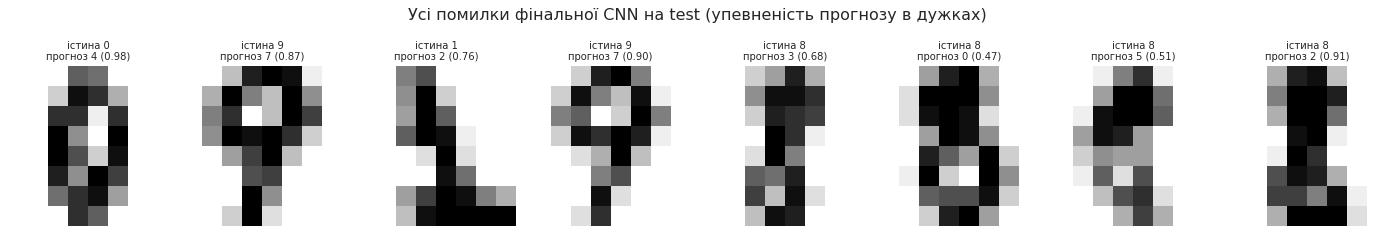

In [9]:
proba = final_model.predict(Xte, verbose=0)
wrong = np.where(pred_dl != yte)[0]
print("Помилок CNN на test:", len(wrong), "із", len(yte))
if len(wrong):
    n = len(wrong)
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.8), squeeze=False)
    for ax, i in zip(axes[0], wrong):
        ax.imshow(Xte[i, ..., 0], cmap="gray_r"); ax.axis("off")
        ax.set_title(f"істина {yte[i]}\nпрогноз {pred_dl[i]} ({proba[i].max():.2f})", fontsize=9)
    plt.tight_layout(); plt.suptitle("Усі помилки фінальної CNN на test (упевненість прогнозу в дужках)", y=1.12); plt.show()

### 5.1. Перевірка стійкості (domain shift)
Реальні дані рідко бувають такими чистими, як навчальні. Змоделюємо два зсуви домену на test: (а) гаусівський шум у пікселях, (б) зсув зображення на 1 піксель. Цікавить не лише точність, а й те, **яка модель деградує сильніше**.

In [10]:
ds = CFG["domain_shift"]
rng = np.random.default_rng(SEED)
Xte_noise = np.clip(Xte + rng.normal(0, ds["gaussian_noise_std"] / 16, Xte.shape), 0, 1).astype("float32")
k = ds["shift_pixels"]
Xte_shift = np.zeros_like(Xte); Xte_shift[:, :, k:, :] = Xte[:, :, :-k, :]          # зсув праворуч на k пікселів

rows = []
for name, Xs in [("чистий test", Xte), ("шум σ=3/16", Xte_noise), (f"зсув на {k} px", Xte_shift)]:
    row = {"умова": name, "B0 LogisticRegression": accuracy_score(yte, logreg.predict(flat(Xs)))}
    for rid, m in models.items():
        row[f"CNN {rid}"] = accuracy_score(yte, m.predict(Xs, verbose=0).argmax(1))
    rows.append(row)
shift = pd.DataFrame(rows).set_index("умова")
shift.round(3)

,B0 LogisticRegression,CNN D1,CNN D2,CNN D3
умова,,,,
чистий test,0.964,0.981,0.983,0.978
шум σ=3/16,0.631,0.964,0.961,0.922
зсув на 1 px,0.400,0.750,0.828,0.981


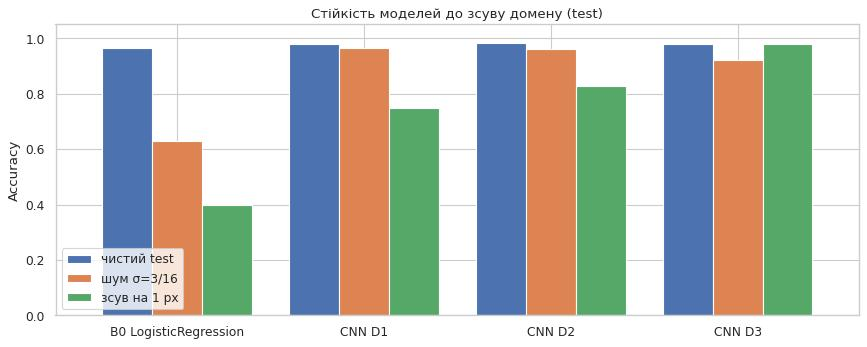

In [11]:
ax = shift.T.plot(kind="bar", figsize=(11, 4.5), rot=0, width=0.8)
ax.set_ylim(0, 1.05); ax.set_ylabel("Accuracy"); ax.set_title("Стійкість моделей до зсуву домену (test)")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

## 6. Збереження результатів

In [12]:
exp_out = exp[["run", "model", "train_acc", "val_acc", "val_macro_f1", "gap", "epochs", "time_s"]].copy()
exp_out.loc[exp_out["run"].isin(CFG["runs"].keys()), "model"] = "CNN"
exp_out["test_acc"] = np.nan
exp_out.loc[exp_out["run"] == "B0", "test_acc"] = final.iloc[0]["test_acc"]
exp_out.loc[exp_out["run"] == best_id, "test_acc"] = final.iloc[1]["test_acc"]
exp_out["selected"] = exp_out["run"].eq(best_id)
exp_out.round(4).to_csv("../results/metrics.csv", index=False)
shift.round(4).to_csv("../results/domain_shift.csv")
os.makedirs("../results/model", exist_ok=True)
final_model.save("../results/model/final_cnn.keras")
print(open("../results/metrics.csv").read())

run,model,train_acc,val_acc,val_macro_f1,gap,epochs,time_s,test_acc,selected
B-rule,most frequent class,0.102,0.1003,,0.0018,,,,False
B0,LogisticRegression,1.0,0.9666,0.9665,0.0334,,0.0287,0.9639,False
D1,CNN,1.0,0.9833,0.9831,0.0167,50.0,17.5611,,False
D2,CNN,1.0,0.9889,0.9887,0.0111,44.0,15.4189,,False
D3,CNN,0.9991,0.9916,0.9915,0.0074,86.0,31.5623,0.9778,True



## 7. Аналітичний висновок (analytical brief)

**Що отримано.** Фінальна модель, CNN D3 (регуляризація та аугментація), на test має **accuracy 0.978** і macro-F1 0.977: 8 помилок із 360. Baseline (логістична регресія) має 0.964, 13 помилок. На validation усі три CNN-run'и перевершили baseline (0.983 / 0.989 / 0.992 проти 0.967). Кожна контрольована зміна (D1 → D2 → D3) трохи підвищувала validation accuracy і зменшувала розрив train/val з 0.017 до 0.007.

**Чи доречне DL.** На чистих даних перевага CNN невелика: bootstrap-інтервал різниці CNN − B0 дорівнює [−0.006; 0.036] і включає нуль. На цьому test-наборі перевага **статистично не доведена**. Головний аргумент на користь CNN — **стійкість**. Після зсуву зображення на 1 піксель точність логістичної регресії падає до 0.40, базової CNN D1 до 0.75, а CNN з аугментацією D3 майже не змінюється (0.981). Для реального застосування, де зображення не вирівняні ідеально, ця властивість важливіша за 1–1.5 п.п. на чистому test.

**Де модель не працює.** Половина помилок припадає на цифру 8 (recall 0.89): на зображенні 8×8 її плутають із 0, 2, 3 і 5. Ще дві помилки: 9 → 7, де верхня петля злита зі штрихом. Частина помилок має високу впевненість (0.87–0.98), тобто модель не завжди «знає, що не знає». Аугментація зсувами **погіршила** стійкість до шуму: 0.922 у D3 проти 0.964 у D1. Аугментація допомагає лише проти тих спотворень, які вона моделює.

**Обмеження.** Невеликий набір (1797 зображень), дуже низька роздільність 8×8, чисті сканування обмеженої кількості авторів, один розподіл даних і один seed на run. Результати не можна напряму переносити на реальні зображення високої роздільності.

**Наступний крок.** Додати до аугментації шум, щоб поєднати стійкість до зсуву і до шуму. Оцінити variance за кількома seed або крос-валідацією. Калібрувати впевненість (temperature scaling) і встановити поріг відмови для непевних прогнозів.